# Section 1.3 — Processing Times

*Fitting narrative and design decisions for the processing-time model (Daniel).*

When an activity starts, the simulator must decide **how long it runs**. We
measure the full **start → complete** duration and model it three ways, each
adding context. Every draw is seeded (`RANDOM_SEED = 42`) so a run reproduces
exactly.

| Model | `--mode` | Idea |
|---|---|---|
| **Basic 1** | `distribution` | one fitted scipy distribution *per activity* |
| **Basic 2** | `ml_model` | contextual **point** estimate (gradient boosting) |
| **Advanced I** | `ml_probabilistic` | contextual **distribution** (19 quantile regressors) |

Like §1.6/§1.7, the split is **fit offline, load at runtime**: the fitting side
lives in `train_processing_time_model.py` (reused directly below — not
reimplemented), the runtime side in `simulation/components/process.py`. The
trained artifact is gitignored; regenerate it with `python setup_models.py`.


In [1]:
import sys, json
sys.path.insert(0, "..")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import train_processing_time_model as T          # fitting side (reused)
from simulation.components import process as P    # runtime side

ROOT = Path("..")
LOG = next((ROOT / c for c in [
    "BPIChallenge2017.xes", "BPIChallenge2017.xes.gz",
    "data/BPIChallenge2017.xes", "data/BPIChallenge2017.xes.gz",
] if (ROOT / c).is_file()), None)

ARTIFACT = ROOT / "simulation" / "models" / "processing_time_model.joblib"
art = joblib.load(ARTIFACT) if ARTIFACT.is_file() else None
METRICS = json.load(open(ROOT / "output" / "models" / "processing_time_metrics.json"))

print("raw log :", LOG if LOG else "NOT FOUND (log-dependent cells self-skip)")
print("artifact:", "loaded" if art else "MISSING -> run  python setup_models.py")
print("features:", T.FEATURE_NAMES)


raw log : ../BPIChallenge2017.xes
artifact: loaded
features: ['activity_enc', 'resource_enc', 'previous_activity_enc', 'day_of_week', 'hour_of_day', 'case_position', 'case_age_seconds', 'n_previous_activities']


---
## Basic 1 — one distribution per activity

The simplest model ignores context: fit a parametric distribution to each
activity's observed durations and sample from it at runtime. `process.py` ships
the fitted parameters in `PROCESSING_TIME_PARAMS`, choosing per activity among
**log-normal, gamma, and Weibull** (best fit), with an **exponential fallback**
where data are too sparse.


In [2]:
params = P.PROCESSING_TIME_PARAMS
families = pd.Series([v[0] for v in params.values()]).value_counts()
print(f"{len(params)} activities carry a fitted distribution; "
      f"{len(P.FALLBACK_MEAN_DURATIONS)} rely on the exponential fallback.\n")
print(families.to_string())


6 activities carry a fitted distribution; 20 rely on the exponential fallback.

lognorm        3
gamma          2
weibull_min    1


[load] Reading XES with pm4py: ../BPIChallenge2017.xes …


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 1/31509 [00:00<3:01:36,  2.89it/s]

parsing log, completed traces ::   0%|          | 136/31509 [00:00<01:19, 396.59it/s]

parsing log, completed traces ::   1%|          | 276/31509 [00:00<00:45, 691.05it/s]

...

parsing log, completed traces ::  99%|█████████▉| 31336/31509 [00:27<00:00, 1331.75it/s]

parsing log, completed traces :: 100%|█████████▉| 31480/31509 [00:27<00:00, 1358.71it/s]

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:27<00:00, 1159.91it/s]

[load] 1,202,267 events, 31,509 cases, 26 activities.


[instances] 41,862 paired instances → 41,862 after duration filter (0 < d ≤ 365d).
41,862 activity instances | median 0.52 h | p95 151.6 h | max 3814 h


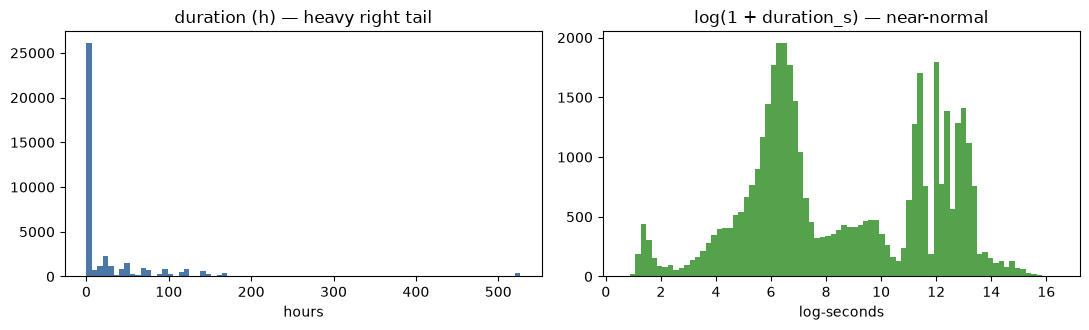

In [3]:
# Why a skewed parametric family at all? Look at the raw durations.
inst = None
if LOG is not None:
    df = T.load_log(LOG)
    inst = T.build_instances(df)
    dur_h = inst["duration_s"] / 3600.0
    print(f"{len(inst):,} activity instances | median {dur_h.median():.2f} h | "
          f"p95 {dur_h.quantile(0.95):.1f} h | max {dur_h.max():.0f} h")
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].hist(dur_h.clip(upper=dur_h.quantile(0.99)), bins=80, color="#4C78A8")
    ax[0].set_title("duration (h) — heavy right tail"); ax[0].set_xlabel("hours")
    ax[1].hist(np.log1p(inst["duration_s"]), bins=80, color="#54A24B")
    ax[1].set_title("log(1 + duration_s) — near-normal"); ax[1].set_xlabel("log-seconds")
    plt.tight_layout(); plt.show()
else:
    print("Raw log not present — skipping the empirical-distribution plot.")


> **Decision 1 — model `log(1 + duration)`, not the duration.** Durations span
> seconds to weeks with a heavy right tail (left panel); in log space they are
> roughly symmetric (right panel). Every context-aware model below therefore
> predicts the log-duration and inverts with `expm1`. Reporting a raw-scale
> $R^2$ alone would look worthless; log-scale alone would hide the large
> absolute tail errors — so we report both.


---
## Basic 2 — contextual point model

To make duration depend on *who* runs the activity and *where* the case is, a
`GradientBoostingRegressor` predicts `log(1 + duration)` from **8 features**
(`train_processing_time_model.FEATURE_NAMES`): label-encoded `activity`,
`resource`, `previous_activity`, plus `day_of_week`, `hour_of_day`,
`case_position`, `case_age_seconds`, `n_previous_activities`.


held-out fit (temporal_80_20): train 33,489 / test 8,373
  log-R2 0.119 | raw-R2 -0.053 | MAE 30.8 h | RMSE 103.2 h


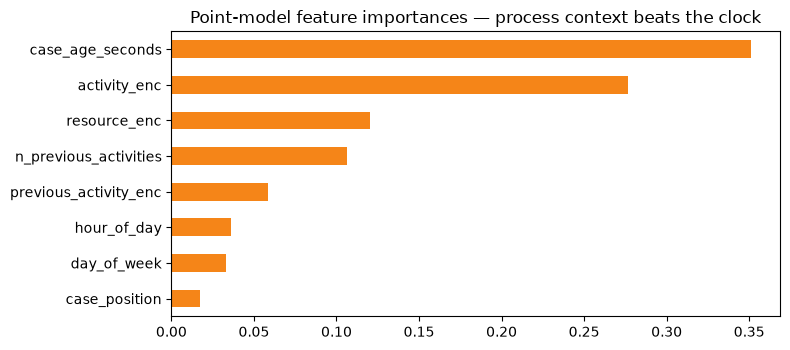

In [4]:
pm = METRICS["point_model"]
print(f"held-out fit ({pm['split']}): train {pm['n_train']:,} / test {pm['n_test']:,}")
print(f"  log-R2 {pm['r2_log']:.3f} | raw-R2 {pm['r2_raw']:.3f} | "
      f"MAE {pm['mae_seconds']/3600:.1f} h | RMSE {pm['rmse_seconds']/3600:.1f} h")

fi = pd.Series(METRICS["feature_importances"]).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
fi.plot.barh(ax=ax, color="#F58518")
ax.set_title("Point-model feature importances — process context beats the clock")
plt.tight_layout(); plt.show()


> **Decision 2 — evaluate on a temporal 80/20 split, not a random one.** We
> train on the oldest ~33.5k instances and test on the most recent ~8.4k. A
> random split leaks process drift (neighbouring events of the same period land
> on both sides) and *overstated* the model — the identical model scored
> log-$R^2$ **0.36** under a random split versus **0.12** temporally. We report
> the smaller, honest number. The importances confirm the model learns process
> context (`case_age` 0.35, `activity` 0.28, `resource` 0.12) rather than clock
> artefacts (each calendar feature < 0.04).


---
## Advanced I — quantile-regression distribution model

A point estimate collapses each context to one value and cannot express the
variation between otherwise-similar cases. We instead fit **19 quantile
regressors** ($q = 0.05, 0.10, \dots, 0.95$) on the same features; together
they describe the *conditional duration curve* for a context. Below we predict
that curve for one context and show the two runtime steps: monotonicity repair,
then inverse-CDF sampling.


context activity : 'W_Validate application'
raw crossings    : 5 of 18 adjacent quantile steps


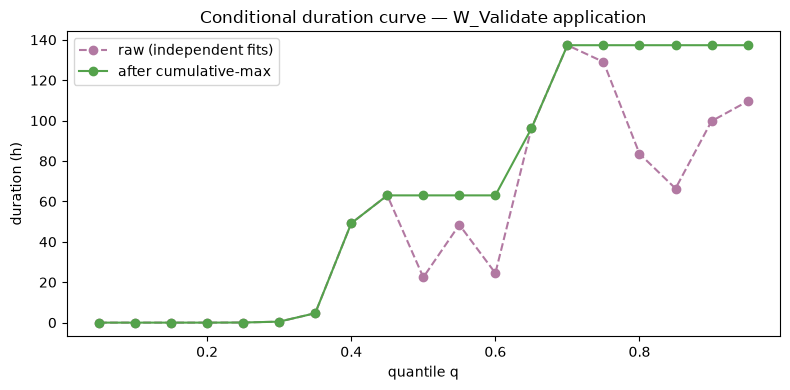

In [5]:
def feature_vector(activity, resource, prev_activity,
                   day=1, hour=11, position=5, case_age_s=3*24*3600, n_prev=5):
    enc, sent = art["encoders"], art["sentinels"]
    def code(name, val, fb):
        val = val if val in set(enc[name].classes_) else fb
        return int(enc[name].transform([val])[0])
    vals = {
        "activity_enc": code("activity", activity, sent["unknown"]),
        "resource_enc": code("resource", resource, sent["unknown"]),
        "previous_activity_enc": code("previous_activity", prev_activity, sent["no_prev"]),
        "day_of_week": day, "hour_of_day": hour, "case_position": position,
        "case_age_seconds": case_age_s, "n_previous_activities": n_prev,
    }
    return np.array([[vals[n] for n in art["feature_names"]]], dtype=float)

acts = [c for c in art["encoders"]["activity"].classes_ if not c.startswith("__")]
ctx_act = "W_Validate application" if "W_Validate application" in acts else acts[0]
x = feature_vector(ctx_act, art["sentinels"]["unknown"], art["sentinels"]["no_prev"])

qs = [float(q) for q in art["quantiles"]]
raw_log  = np.array([art["quantile_models"][q].predict(x)[0] for q in art["quantiles"]])
mono_log = np.maximum.accumulate(raw_log)          # the fix used in process.py
n_cross  = int((np.diff(raw_log) < 0).sum())
print(f"context activity : {ctx_act!r}")
print(f"raw crossings    : {n_cross} of {len(qs)-1} adjacent quantile steps")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(qs, np.expm1(raw_log)/3600,  "o--", color="#B279A2", label="raw (independent fits)")
ax.plot(qs, np.expm1(mono_log)/3600, "o-",  color="#54A24B", label="after cumulative-max")
ax.set_xlabel("quantile q"); ax.set_ylabel("duration (h)")
ax.set_title(f"Conditional duration curve — {ctx_act}")
ax.legend(); plt.tight_layout(); plt.show()


> **Decision 3 — enforce monotonicity before sampling.** Because the 19
> quantiles are fit independently, neighbouring predictions can cross (a
> non-monotone, invalid CDF). At sample time we sort each predicted curve into a
> non-decreasing one with a **cumulative maximum in log space**
> (`np.maximum.accumulate`, see `process.py::_sample_duration_ml_prob`), rather
> than paying for jointly-constrained quantile fitting.


sampled median 62.99 h | p95 137.3 h  (a point model would return one fixed value here)


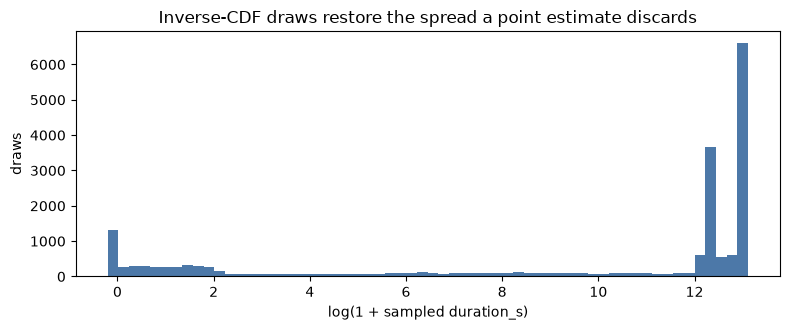

In [6]:
# Inverse-CDF sampling: draw u ~ Uniform(0,1), interpolate the sorted curve.
rng = np.random.default_rng(T.RANDOM_SEED)
u = rng.random(20000)
samples_s = np.expm1(np.interp(u, qs, mono_log))
samples_h = samples_s / 3600.0
print(f"sampled median {np.median(samples_h):.2f} h | "
      f"p95 {np.quantile(samples_h, 0.95):.1f} h  "
      f"(a point model would return one fixed value here)")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(np.log1p(samples_s), bins=60, color="#4C78A8")
ax.set_xlabel("log(1 + sampled duration_s)"); ax.set_ylabel("draws")
ax.set_title("Inverse-CDF draws restore the spread a point estimate discards")
plt.tight_layout(); plt.show()


In [7]:
qe = METRICS["quantile_eval"]
print(f"mean pinball loss (log) : {qe['mean_pinball_loss_log']:.3f}")
print(f"90% interval coverage   : {qe['coverage_90pct_interval']:.2f}   (nominal 0.90)")
print(f"50% interval coverage   : {qe['coverage_50pct_interval']:.2f}   (nominal 0.50)")


mean pinball loss (log) : 0.853
90% interval coverage   : 0.81   (nominal 0.90)
50% interval coverage   : 0.42   (nominal 0.50)


> **Decision 4 — score the distribution with pinball loss + interval coverage.**
> The mean log-scale pinball loss is 0.85; the nominal 90% and 50% intervals
> cover 81% and 42% of test cases — somewhat narrow, i.e. mildly over-confident,
> which we report rather than tune away. The quantile model is therefore a more
> expressive *stochastic approximation*, not an exact per-instance predictor.


---
## Second pass — effect on the simulated log

Running the three modes through a 30-day simulation (seed 42), each step up in
context-awareness widens the simulated duration spread toward realistic values.
Longer sampled durations also leave more cases in flight at the fixed horizon,
so "cases completed" must be read together with the horizon and the drain
analysis (§ branching).


In [8]:
second_pass = pd.DataFrame(
    {
        "fitted (Basic 1)":  [0.05, 16.0,   6.9, 2177],
        "point (Basic 2)":   [2.65, 17.7,  33.4, 2023],
        "quantile (Adv. I)": [7.41, 45.8, 121.8, 1058],
    },
    index=["median dur (h)", "std dur (h)", "p95 dur (h)", "cases completed"],
).T
second_pass


,median dur (h),std dur (h),p95 dur (h),cases completed
fitted (Basic 1),0.05,16.0,6.9,2177.0
point (Basic 2),2.65,17.7,33.4,2023.0
quantile (Adv. I),7.41,45.8,121.8,1058.0


**Takeaway.** The point model lifts the median but keeps the tail compressed;
only the quantile model restores tail mass (std 16.0 → 17.7 → **45.8** h) — the
entire purpose of the advanced tier. That realism costs completions inside a
fixed horizon (2177 → 1058), a survivorship effect, not a defect.

*Reproduce:* `python setup_models.py` (trains the artifact from the raw log),
then `python -m simulation.main --mode {distribution,ml_model,ml_probabilistic}`.
